<a href="https://colab.research.google.com/github/ram1014/colab_files/blob/main/practica_evaluacion_seleccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - 14/11/2025
## Práctica: Validación, Evaluación y Selección
---


## Datos del Estudiante

*   Apellidos y Nombre: Ramon Humberto Delgado Andrade
*   Matrícula:263165


In [ ]:
#for google colab
from google.colab import drive
drive.mount('/content/drive')

## Carga de Bibliotecas, Conjunto de Datos y Análisis Exploratorio de los Datos

* Declarar las bibliotecas necesarias para este proyecto
* Cargar el conjunto de datos Glioma Grading Clinical and Mutation Features.
Se puede descargar de

https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import math
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.datasets import load_wine
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, GridSearchCV
from scipy.stats import randint

In [ ]:
#load dataframe local
#df = pd.read_csv("TCGA_InfoWithGrade.csv")
#load dataframe google
df = pd.read_csv("/content/drive/MyDxticks(rotation=45)rive/ClassFiles/TCGA_InfoWithGrade.csv")


## 📊 Análisis exploratorio de datos (EDA)

Realiza un análisis inicial de los datos antes de modelar:

    Describir forma y estructura (shape, describe(), info()).

    Mostrar la distribución de clases (y.value_counts()).

    Visualizar:

        Histograma de al menos 3 variables numéricas.

        Boxplots o violin plots por clase si es computacionalmente viable.

        Mapa de calor de correlaciones entre variables.



In [ ]:
display(df.head())
display(df.info())
display(df[['Age_at_diagnosis']].describe())

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 839 entries, 0 to 838
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Grade             839 non-null    int64  
 1   Gender            839 non-null    int64  
 2   Age_at_diagnosis  839 non-null    float64
 3   Race              839 non-null    int64  
 4   IDH1              839 non-null    int64  
 5   TP53              839 non-null    int64  
 6   ATRX              839 non-null    int64  
 7   PTEN              839 non-null    int64  
 8   EGFR              839 non-null    int64  
 9   CIC               839 non-null    int64  
 10  MUC16             839 non-null    int64  
 11  PIK3CA            839 non-null    int64  
 12  NF1               839 non-null    int64  
 13  PIK3R1            839 non-null    int64  
 14  FUBP1             839 non-null    int64  
 15  RB1               839 non-null    int64  
 16  NOTCH1            839 non-null    int64  
 1

None

,Age_at_diagnosis
count,839.000000
mean,50.935411
std,15.702339
min,14.420000
25%,38.055000
50%,51.550000
75%,62.800000
max,89.290000


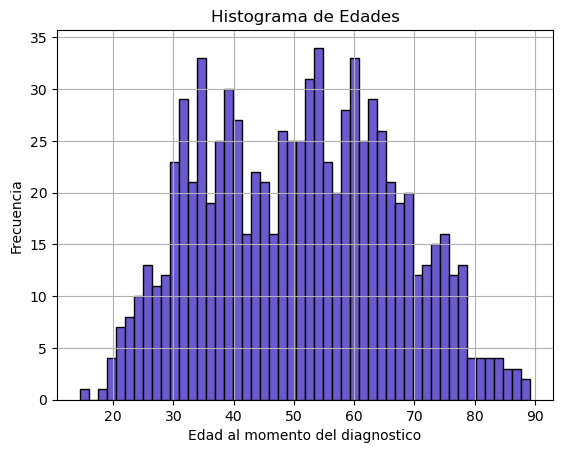

In [ ]:
df['Age_at_diagnosis'].hist(bins=50, edgecolor='black',color='slateblue')
plt.title('Histograma de Edades')
plt.xlabel('Edad al momento del diagnostico')
plt.ylabel('Frecuencia')
plt.show()

Estadísticas para Edaded:
Q1 - 1.5IQR = 0.94
Q1 = 38.05
Mediana = 51.55
Q3 = 62.80
Q3 + 1.5IQR = 99.92
Número de observaciones: 839
Número de outliers: 0


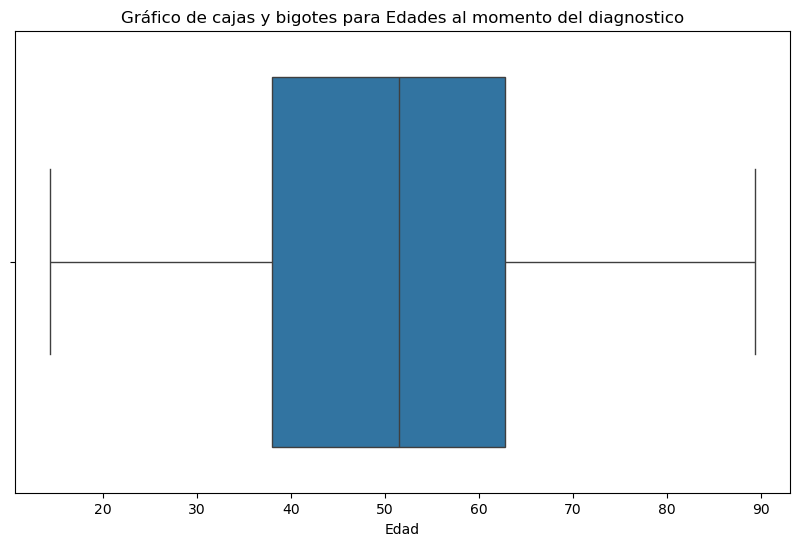

In [ ]:
# Estadísticas necesarias para reproducir el gráfico de cajas y bigotes
Q1 = df['Age_at_diagnosis'].quantile(0.25)
Q3 = df['Age_at_diagnosis'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Estadísticas para Edaded:")
print(f"Q1 - 1.5IQR = {lower_bound:.2f}")
print(f"Q1 = {Q1:.2f}")
print(f"Mediana = {df['Age_at_diagnosis'].median():.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"Q3 + 1.5IQR = {upper_bound:.2f}")
print(f"Número de observaciones: {len(df['Age_at_diagnosis'])}")
print(f"Número de outliers: {sum((df['Age_at_diagnosis'] < lower_bound) | (df['Age_at_diagnosis'] > upper_bound))}")

# Construcción del gráfico de cajas y bigotes
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Age_at_diagnosis'])
plt.title('Gráfico de cajas y bigotes para Edades al momento del diagnostico')
plt.xlabel('Edad')
plt.show()

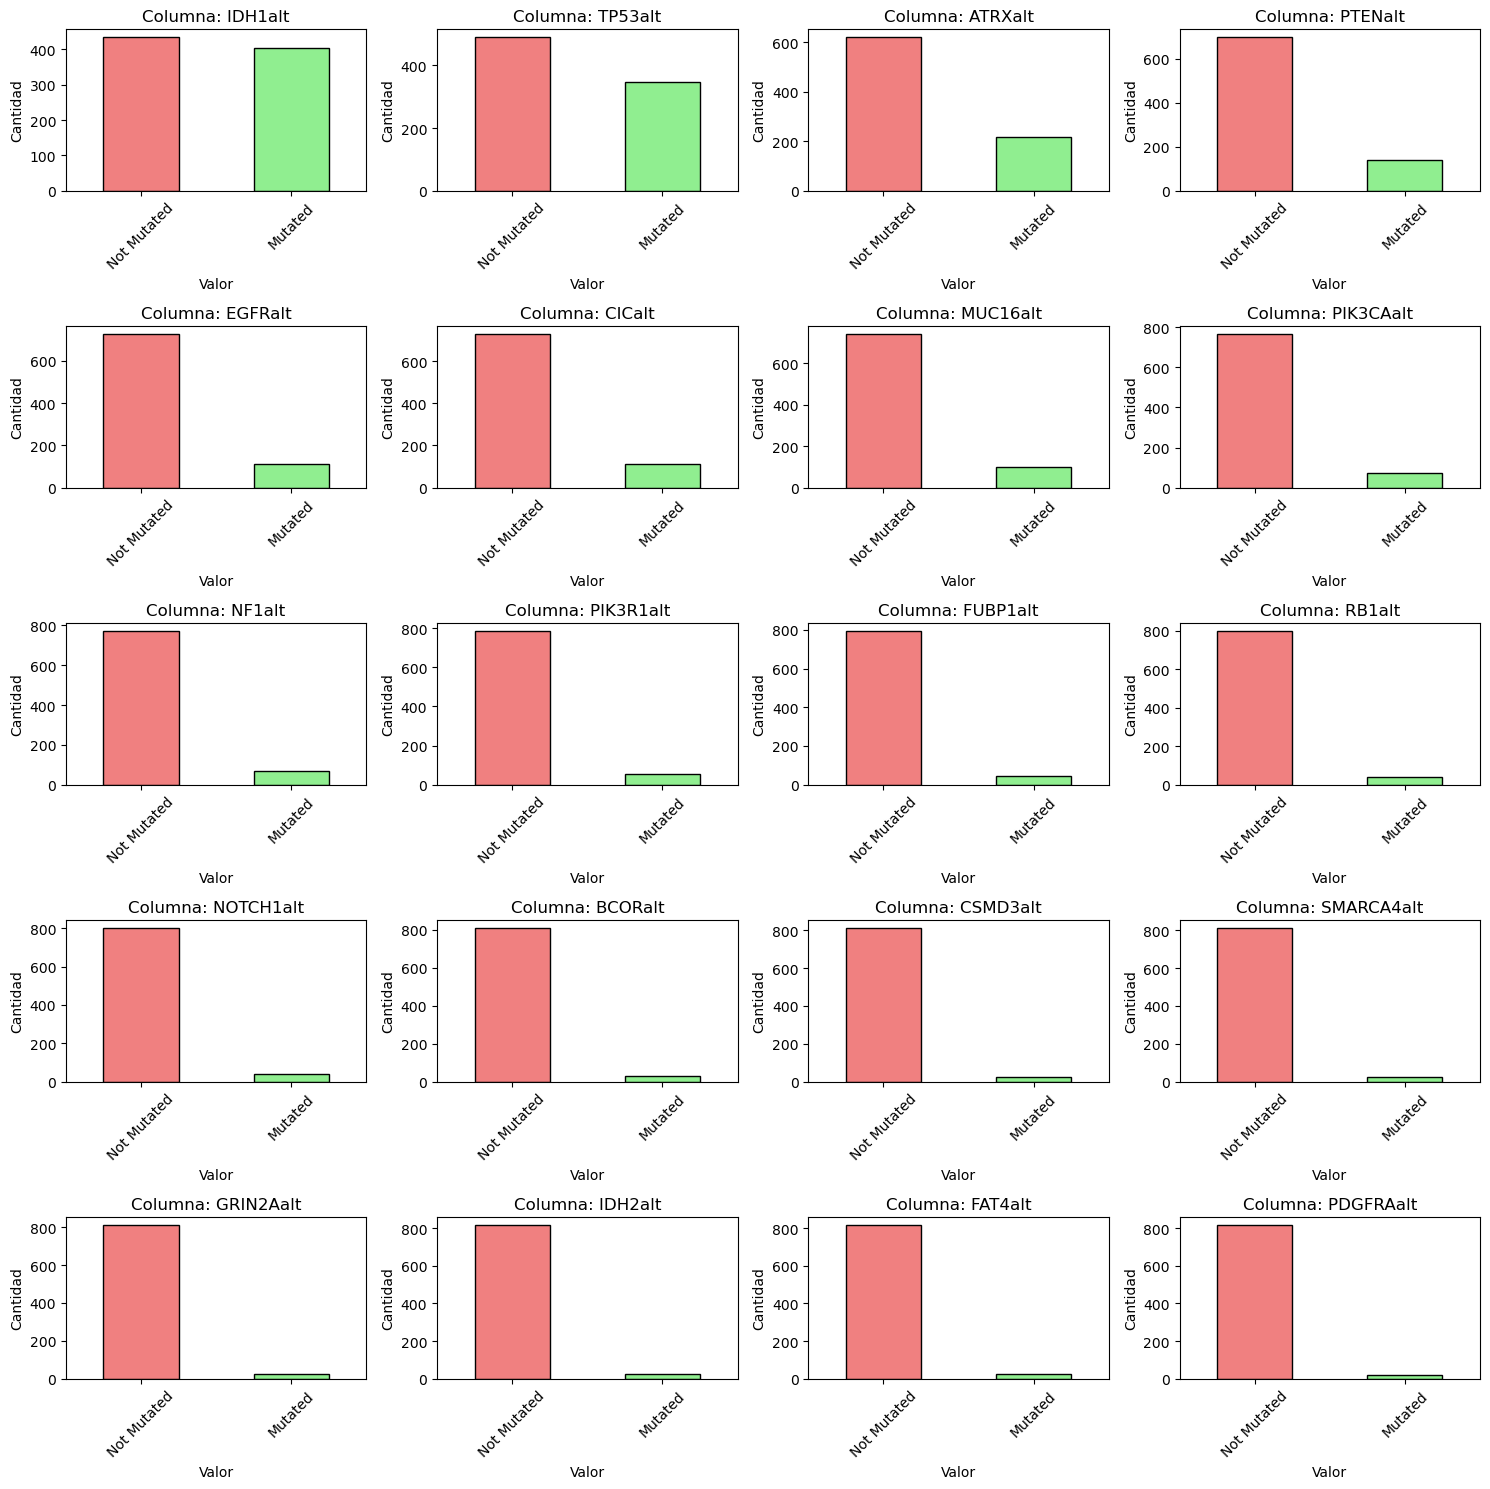

In [ ]:
mut_cols = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1',
                'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']
mut_cols2 = []
for col in mut_cols:
    df[col+'alt'] = df[col].map({1: 'Mutated', 0: 'Not Mutated'})
    mut_cols2.append(col+'alt')
# Graficar conteos para cada columna
fig, axes = plt.subplots(5, len(mut_cols2)//5, figsize=(15, 15))

i = 0
j = 0
for col in mut_cols2:
    conteo = df[col].value_counts()
    conteo.plot(kind='bar', ax=axes[i,j], color=['lightcoral', 'lightgreen'], edgecolor='black')
    axes[i,j].set_title(f'Columna: {col}')
    axes[i,j].set_xlabel('Valor')
    axes[i,j].set_ylabel('Cantidad')
    axes[i,j].tick_params(axis='x', labelrotation=45)
    j += 1
    if j == 4:
        i += 1
        j = 0

plt.tight_layout()
plt.show()

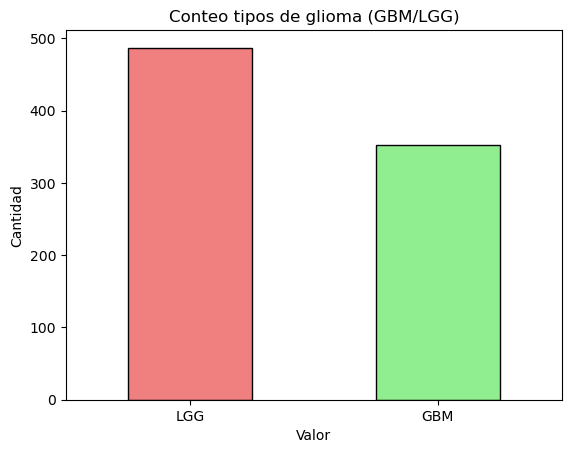

In [ ]:
df['Gradealt'] = df['Grade'].map({1: 'GBM', 0: 'LGG'})
conteo = df['Gradealt'].value_counts()
# Graficar
conteo.plot(kind='bar', color=['lightcoral', 'lightgreen'], edgecolor='black')
plt.title('Conteo tipos de glioma (GBM/LGG)')
plt.xlabel('Valor')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

Matriz de correlación:
                     Grade    Gender  Age_at_diagnosis      Race      IDH1  \
Grade             1.000000 -0.060033          0.529203  0.080084 -0.708141   
Gender           -0.060033  1.000000         -0.016337 -0.004267  0.048282   
Age_at_diagnosis  0.529203 -0.016337          1.000000  0.018327 -0.568892   
Race              0.080084 -0.004267          0.018327  1.000000 -0.079718   
IDH1             -0.708141  0.048282         -0.568892 -0.079718  1.000000   
TP53             -0.161786  0.002022         -0.315863 -0.087353  0.340995   
ATRX             -0.314625  0.056376         -0.418411 -0.031540  0.454920   
PTEN              0.367174 -0.032233          0.259421  0.016188 -0.394862   
EGFR              0.241527 -0.034497          0.227660  0.028343 -0.357217   
CIC              -0.303459  0.061063         -0.122851 -0.037230  0.320696   
MUC16             0.119447  0.015054          0.089834  0.014952 -0.097956   
PIK3CA            0.028905 -0.004629     

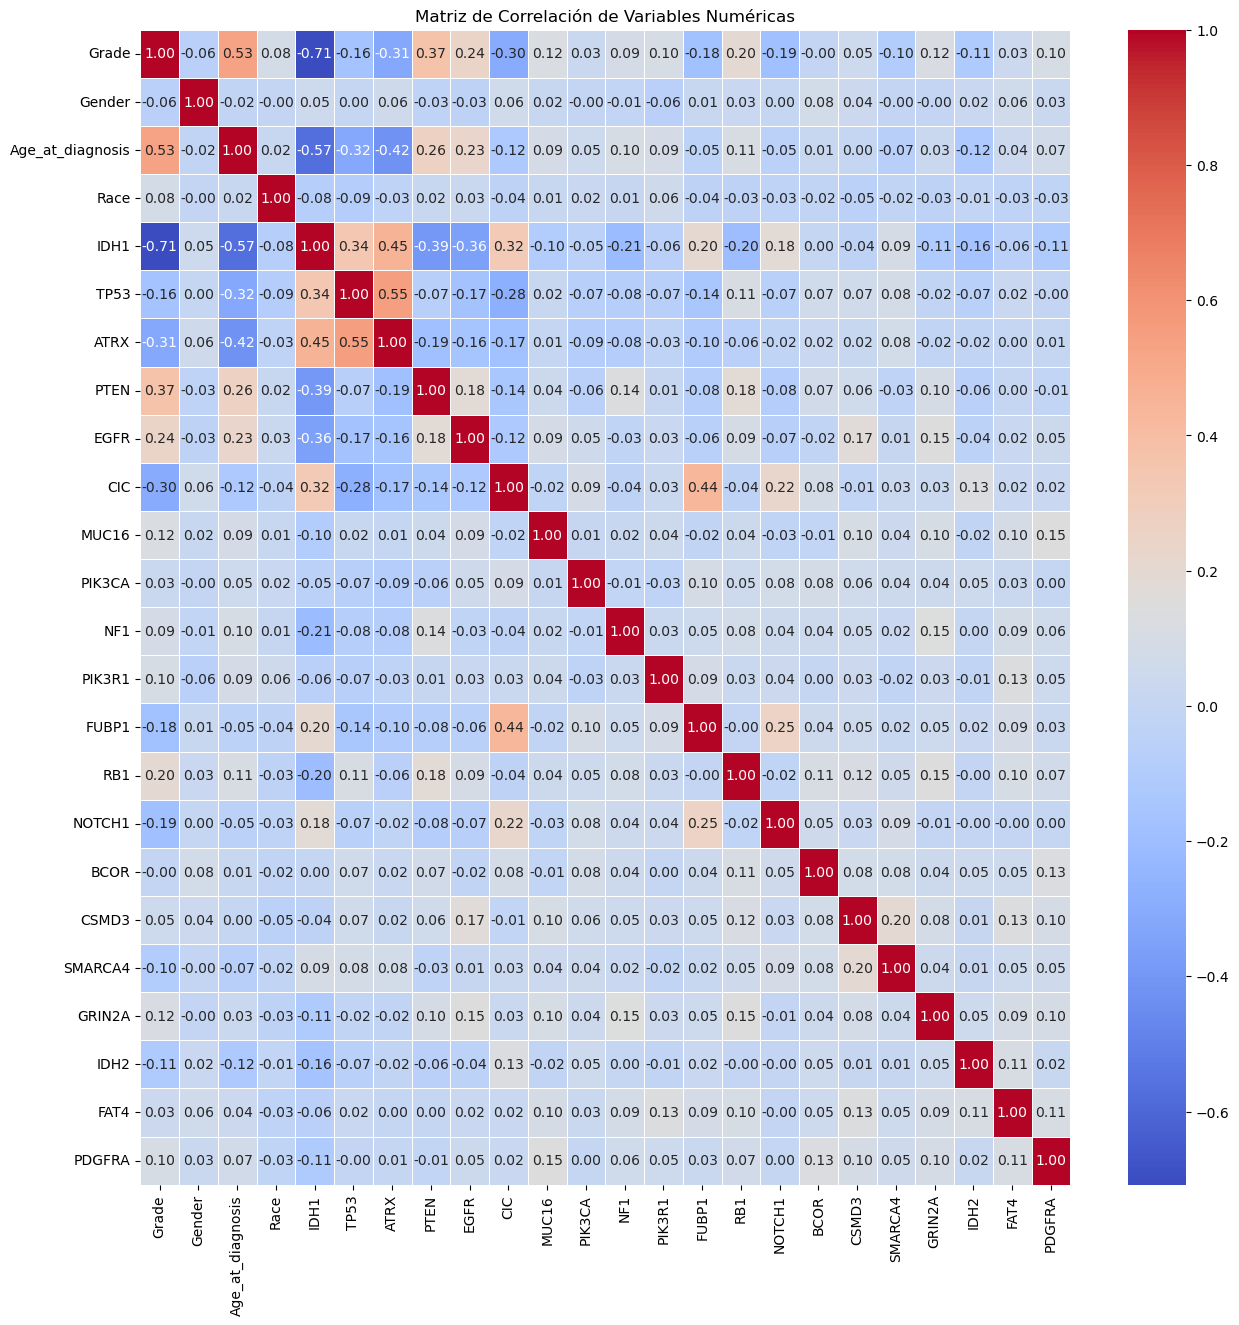

In [ ]:
# Seleccionar solo las columnas numéricas
numeric_columns = df.select_dtypes(include=[np.number])

# Calcular la matriz de correlación
corr_matrix = numeric_columns.corr()

# Mostrar la matriz de correlación
print("Matriz de correlación:")
print(corr_matrix)

# Visualizar la matriz de correlación con un heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

🧠 Reflexiona:

    ¿Existen clases desbalanceadas?
    
    Parece que las clases estan ligeramente balanceadas.
    
    ¿Qué atributos parecen más informativos?

    Pareciera que los datos que mayo aporte dan a la informacion son la "edad a la hora del dagnostico" y el gen 'IDH1'


## Gráfica de Errores en Entrenamiento y Prueba

*     En este ejercicio vas a entrenar un árbol de decisión con diferentes profundidas. Asimismo, en gráfica mostrarás las exactitudes en entrenamiento y test, usando un stratified k-fold cross-validation con K= 10
*     Los valores de las profundides a evaluar son 2, 5, 10, 15, 20, 25, 30 y None
*     Deberás usar StratifiedKFold con 10 particiones, y un valor aleaotorio de 3
*     Entrenarás y evaluarás un árbol de decisión con estos distintos valores de profundidades
*     Usa cross_val_score para entrenar los modelos, usando como métrica de evaluación en scoring ="f1_macro",y el StratifiedKFold, con un valor aleatorio = 7
*     Muestra una fráfica para los distintos resultados  cuando se usa F1 Macro


In [ ]:
x_cols = ['Age_at_diagnosis','Gender', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1',
                'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']
y_cols = ['Grade']

X = df[x_cols]
y = df[y_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

train_accuracies = []
test_accuracies = []
depths = [2, 5, 10, 15, 20, 25, 30, None]

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

### Graficar errores en entrenamiento y prueba

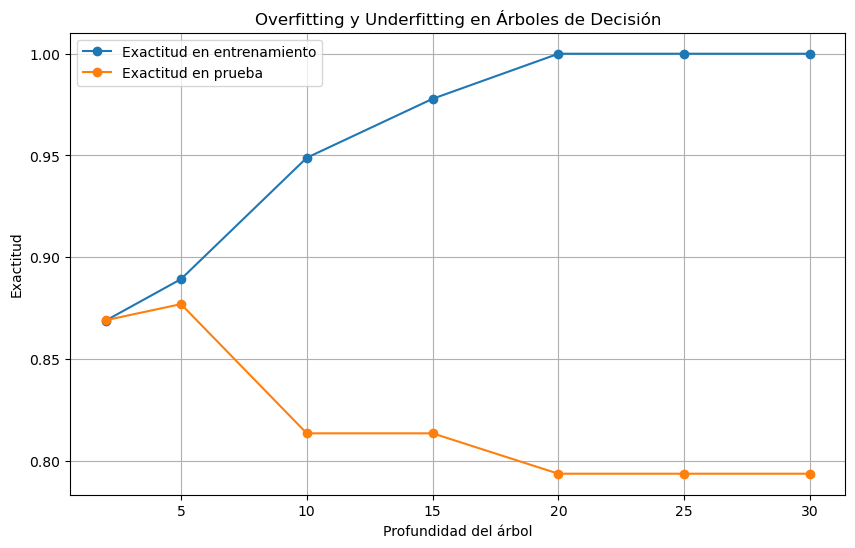

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(depths, train_accuracies, label='Exactitud en entrenamiento', marker='o')
plt.plot(depths, test_accuracies, label='Exactitud en prueba', marker='o')
plt.xlabel('Profundidad del árbol')
plt.ylabel('Exactitud')
plt.title('Overfitting y Underfitting en Árboles de Decisión')
plt.legend()
plt.grid(True)
plt.show()

## Optimización de hiperparámetros con RandomizedSearchCV

* Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:
     * Criterion = gini ,entropy
     * max_depth: de 5 a 50 con incrementos de 1
     * min_samples_split: de 2 a 20 con incrementos de 1
* Usa el árbol de decisión
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* n_iter = 5 (combinaciones aleatorias a buscar)
* n_jobs = -1 para acelerar cómputo
* Métrica de evaluación: f1 Macro
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score


In [ ]:
#Árbol de Decisión con RandomizedSearchCV y StratifiedKFold


# 1. Cargar datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Definir modelo base
clf = DecisionTreeClassifier(random_state=42)

# 3. Definir espacio de búsqueda
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(5, 51),
    'min_samples_split': randint(2, 21)
}

# 4. Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 5. Configurar búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=5,              # Número de combinaciones aleatorias a probar
    cv=cv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# 6. Ajustar el modelo
random_search.fit(X_train, y_train)

# 7. Resultados
print("Mejores hiperparámetros encontrados:", random_search.best_params_)
print("Precisión en test:", accuracy_score(y_test, random_search.predict(X_test)))
display("F1 Macro: ", f1_score(y_test, random_search.predict(X_test), average='macro'))

Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 33, 'min_samples_split': 16}
Precisión en test: 0.8055555555555556


'F1 Macro: '

0.7991509295857122

## Optimización de hiperparámetros con GridSearchCV

* Define el espacio de búsqueda  para los siguientes hiperpárametros:
     * Criterion = gini ,entropy
     * max_depth: de 5 a 50 con incrementos de 1
     * min_samples_split: de 2 a 20 con incrementos de 1
* Usa el árbol de decisión
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* Métrica de evaluación: f1 Macro
* n_jobs = -1 para acelerar cómputo
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score


In [ ]:
# 1. Cargar datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Definir modelo base
clf = DecisionTreeClassifier(random_state=42)

# 3. Definir espacio de búsqueda
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(5,51),
    'min_samples_split': range(2,21)
}

# 4. Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 5. Configurar GridSearchCV
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

# 6. Ajustar modelo
grid_search.fit(X_train, y_train)

# 7. Resultados
display("Mejores hiperparámetros encontrados:", grid_search.best_params_)
display("Exactitud en test:", accuracy_score(y_test, grid_search.predict(X_test)))
display("F1 Macro: ", f1_score(y_test, grid_search.predict(X_test), average='macro'))

'Mejores hiperparámetros encontrados:'

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}

'Exactitud en test:'

0.8611111111111112

'F1 Macro: '

0.8599444223898371

## Actividad de reflexión y análisis

    ¿Cuál método encontró mejores hiperparámetros?

**fue GridSearchCV**
    
    ¿Cuál fue más costoso computacionalmente?

**fue GridSearchCV**

  
    ¿Los resultados en f1_macro set fueron distintos en ambos métodos de optimización? ¿Por qué?

**si, para GridSearchCV, el resultado de f1_macro fue mejor**

  
    ¿Los resultados en accuracy set fueron distintos en ambos métodos de optimización? ¿Por qué?

**si, en GridSearchCV se obtuvieron mejores metricos para Accuracy, creo que porque el grid search evaluo todas las posibilidades, mientras que RandomizedSearchCV no prueba todas las combinaciones posibles.**

  
    ¿Los valores de hiperpárametros fueron iguales en Accuracy y F1 Macro ?

**No, fueron un poco diferentes.**
